# Final Model Comparison Plots

This notebook visualizes the saved outputs from `model_comparison_final.ipynb`.

Inputs:

- `results/final_model_comparison/validation_results.csv`
- `results/final_model_comparison/test_results_overall.csv`
- `results/final_model_comparison/test_results_breakdowns.csv`
- `results/final_model_comparison/direct_vs_delta_test_results.csv`
- `results/final_model_comparison/test_predictions.parquet`
- `results/final_model_comparison/run_config.json`

## 1. Load Result Artifacts

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

RESULT_DIR = Path("results/final_model_comparison")
FIG_DIR = RESULT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

required = [
    "validation_results.csv",
    "test_results_overall.csv",
    "test_results_breakdowns.csv",
    "direct_vs_delta_test_results.csv",
    "test_predictions.parquet",
    "run_config.json",
]
missing = [p for p in required if not (RESULT_DIR / p).exists()]
if missing:
    raise FileNotFoundError(f"Missing result artifacts: {missing}. Run model_comparison_final.ipynb first.")

validation = pd.read_csv(RESULT_DIR / "validation_results.csv")
test_overall = pd.read_csv(RESULT_DIR / "test_results_overall.csv")
breakdowns = pd.read_csv(RESULT_DIR / "test_results_breakdowns.csv")
delta = pd.read_csv(RESULT_DIR / "direct_vs_delta_test_results.csv")
predictions = pd.read_parquet(RESULT_DIR / "test_predictions.parquet")
with open(RESULT_DIR / "run_config.json", "r", encoding="utf-8") as f:
    run_config = json.load(f)

print("Loaded artifacts:")
for name, obj in [
    ("validation", validation),
    ("test_overall", test_overall),
    ("breakdowns", breakdowns),
    ("delta", delta),
    ("predictions", predictions),
]:
    print(f"  {name}: {obj.shape}")
display(test_overall)

Loaded artifacts:
  validation: (44, 10)
  test_overall: (12, 10)
  breakdowns: (168, 10)
  delta: (4, 10)
  predictions: (6902340, 14)


,model,target,target_type,feature_mixture,split,train_rows,evaluation_rows,mae,rmse,r2
0,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.232244,0.407645,0.852031
1,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,test,300000,575195,0.234435,0.412843,0.848233
2,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,150000,575195,0.238833,0.419889,0.843008
3,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.248870,0.434029,0.832256
4,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.248870,0.434029,0.832256
5,persistence,target_next_IRI,direct,persistence,test,3258128,575195,0.263025,0.474531,0.799489
6,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.150635,1.765230,0.840754
7,random_forest,target_next_URA,direct,current_static_lag_lifecycle_material,test,300000,575195,1.141090,1.774198,0.839131
8,gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,150000,575195,1.209294,1.841161,0.826759
9,linear_regression,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.286372,1.923522,0.810913


## 2. Run Configuration and Feature Mixtures

Run configuration:


,setting,value
0,model_data_path,data\road_model_dataset_v2.parquet
1,event_history_path,data\road_event_history_v2.parquet
2,random_state,42


,feature_mixture,n_features,features
0,current,3,"URA, IRI, target_horizon_years"
1,current_static,8,"URA, IRI, target_horizon_years, KVL, KVL_raska..."
2,current_static_lag,11,"URA, IRI, target_horizon_years, KVL, KVL_raska..."
3,current_static_lag_lifecycle,13,"URA, IRI, target_horizon_years, KVL, KVL_raska..."
4,current_static_lag_lifecycle_material,17,"URA, IRI, target_horizon_years, KVL, KVL_raska..."


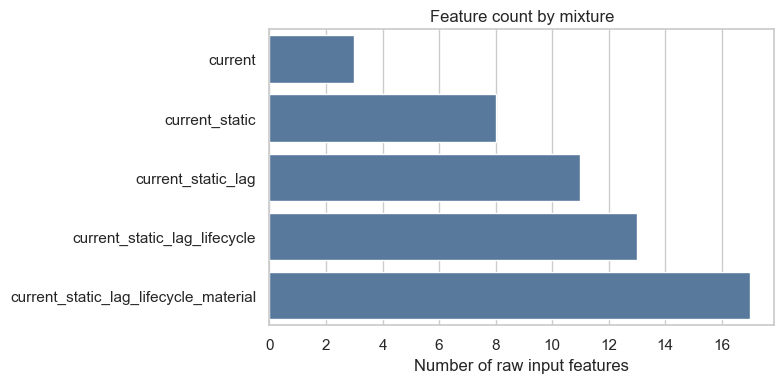

In [2]:
print("Run configuration:")
display(pd.DataFrame({
    "setting": ["model_data_path", "event_history_path", "random_state"],
    "value": [run_config.get("model_data_path"), run_config.get("event_history_path"), run_config.get("random_state")],
}))

feature_rows = []
for name, features in run_config["feature_mixtures"].items():
    feature_rows.append({"feature_mixture": name, "n_features": len(features), "features": ", ".join(features)})
feature_table = pd.DataFrame(feature_rows)
display(feature_table)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_table, y="feature_mixture", x="n_features", color="#4C78A8")
plt.title("Feature count by mixture")
plt.xlabel("Number of raw input features")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_count_by_mixture.png", dpi=160)
plt.show()

## 3. Validation Model Selection

Best validation configuration for each model and target:


,target,model,feature_mixture,train_rows,mae,rmse,r2
1,target_next_IRI,hist_gradient_boosting,current_static_lag_lifecycle_material,"2,683,410",0.233,0.413,0.849
3,target_next_IRI,random_forest,current_static_lag_lifecycle_material,"300,000",0.235,0.418,0.845
0,target_next_IRI,gradient_boosting,current_static_lag_lifecycle_material,"150,000",0.240,0.425,0.840
2,target_next_IRI,linear_regression,current_static_lag_lifecycle_material,"2,683,410",0.250,0.440,0.828
4,target_next_IRI,ridge,current_static_lag_lifecycle_material,"2,683,410",0.250,0.440,0.828
6,target_next_URA,hist_gradient_boosting,current_static_lag_lifecycle_material,"2,683,410",1.149,1.764,0.840
8,target_next_URA,random_forest,current_static_lag_lifecycle_material,"300,000",1.138,1.772,0.839
5,target_next_URA,gradient_boosting,current_static_lag_lifecycle_material,"150,000",1.206,1.838,0.827
9,target_next_URA,ridge,current_static_lag_lifecycle_material,"2,683,410",1.285,1.922,0.811
7,target_next_URA,linear_regression,current_static_lag_lifecycle_material,"2,683,410",1.285,1.922,0.811


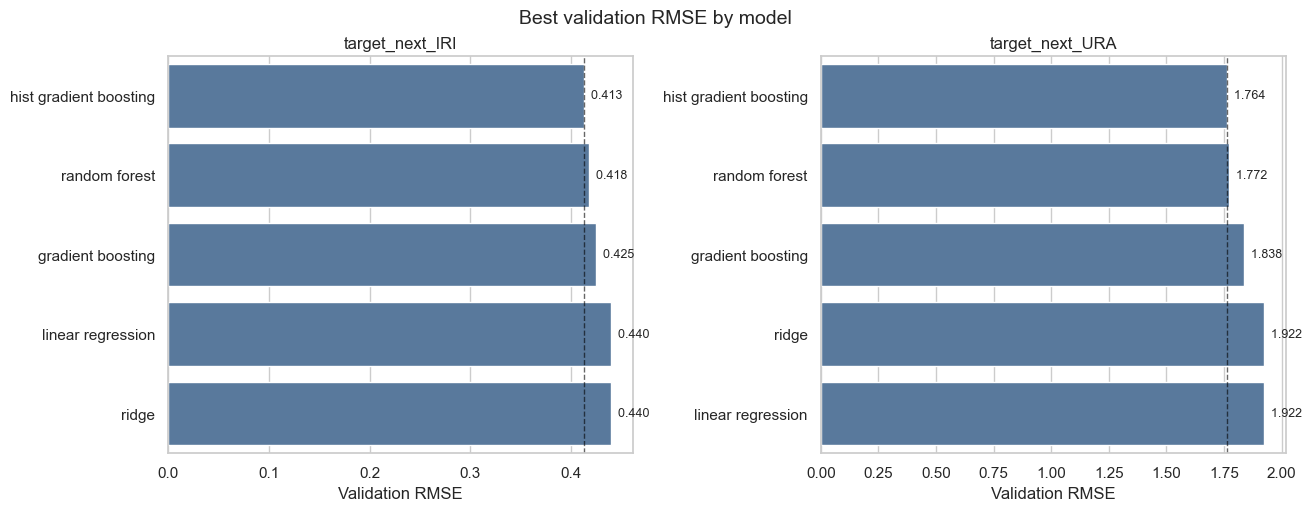

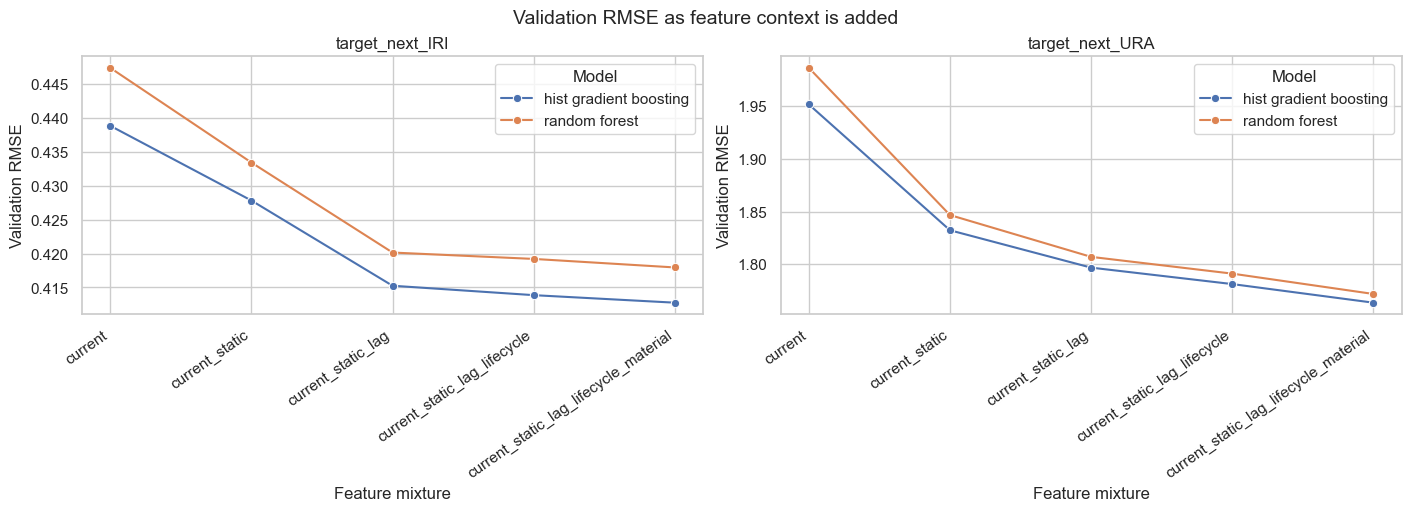

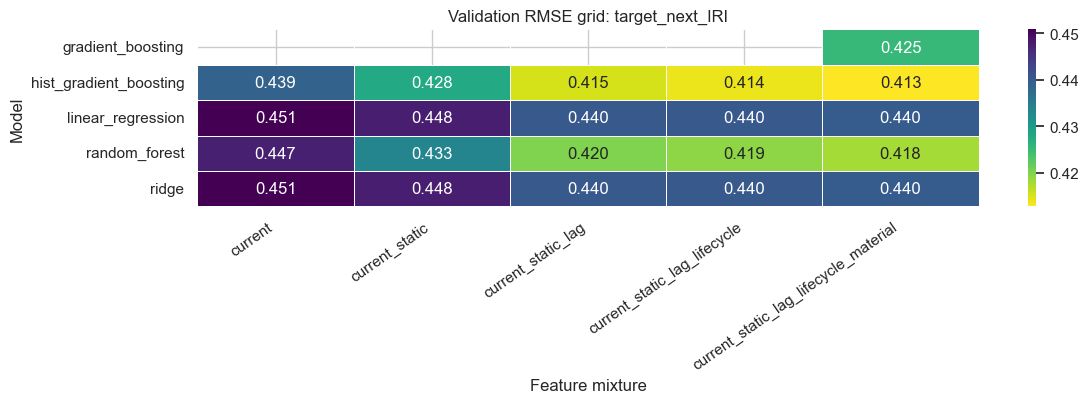

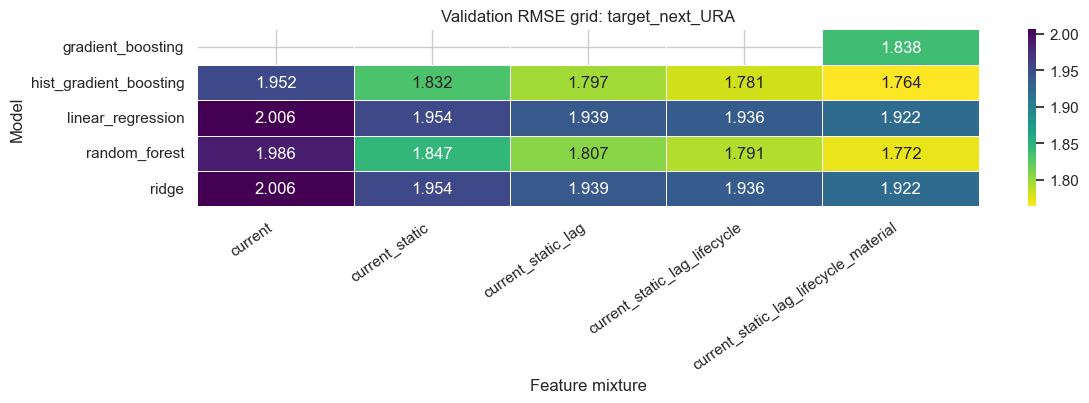

In [3]:
best_validation = (
    validation.loc[validation["model"].ne("persistence")]
    .sort_values("rmse")
    .groupby(["target", "model"], as_index=False)
    .first()
    .sort_values(["target", "rmse"])
)

print("Best validation configuration for each model and target:")
display(
    best_validation[["target", "model", "feature_mixture", "train_rows", "mae", "rmse", "r2"]]
    .style.format({"mae": "{:.3f}", "rmse": "{:.3f}", "r2": "{:.3f}", "train_rows": "{:,}"})
)

# Plot 1: clean model ranking using only each model's best validation configuration.
rank_plot = best_validation.copy()
rank_plot["model_label"] = rank_plot["model"].str.replace("_", " ")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, target in zip(axes, sorted(rank_plot["target"].unique())):
    subset = rank_plot.loc[rank_plot["target"].eq(target)].sort_values("rmse", ascending=True)
    sns.barplot(data=subset, y="model_label", x="rmse", ax=ax, color="#4E79A7")
    ax.set_title(target)
    ax.set_xlabel("Validation RMSE")
    ax.set_ylabel("")
    best_rmse = subset["rmse"].min()
    ax.axvline(best_rmse, color="black", linewidth=1, linestyle="--", alpha=0.6)
    for patch, (_, row) in zip(ax.patches, subset.iterrows()):
        ax.text(
            patch.get_width(),
            patch.get_y() + patch.get_height() / 2,
            f"  {row['rmse']:.3f}",
            va="center",
            fontsize=9,
        )
fig.suptitle("Best validation RMSE by model", fontsize=14)
fig.savefig(FIG_DIR / "validation_best_model_ranking.png", dpi=160, bbox_inches="tight")
plt.show()

# Plot 2: feature-mixture progression for the two strongest model families only.
progress_models = ["hist_gradient_boosting", "random_forest"]
progress = validation.loc[validation["model"].isin(progress_models)].copy()
feature_order = list(run_config["feature_mixtures"].keys())
progress["feature_mixture"] = pd.Categorical(progress["feature_mixture"], categories=feature_order, ordered=True)
progress["model_label"] = progress["model"].str.replace("_", " ")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, target in zip(axes, sorted(progress["target"].unique())):
    subset = progress.loc[progress["target"].eq(target)].sort_values("feature_mixture")
    sns.lineplot(data=subset, x="feature_mixture", y="rmse", hue="model_label", marker="o", ax=ax)
    ax.set_title(target)
    ax.set_xlabel("Feature mixture")
    ax.set_ylabel("Validation RMSE")
    ax.tick_params(axis="x", rotation=35)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    ax.legend(title="Model")
fig.suptitle("Validation RMSE as feature context is added", fontsize=14)
fig.savefig(FIG_DIR / "validation_hgb_rf_feature_progression.png", dpi=160, bbox_inches="tight")
plt.show()

# Plot 3: heatmap keeps the full grid available without an unreadable grouped bar chart.
full_grid = validation.loc[validation["model"].ne("persistence")].copy()
for target in sorted(full_grid["target"].unique()):
    pivot = (
        full_grid.loc[full_grid["target"].eq(target)]
        .pivot_table(index="model", columns="feature_mixture", values="rmse")
        .reindex(columns=feature_order)
    )
    plt.figure(figsize=(12, 4.2))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis_r", linewidths=0.5)
    plt.title(f"Validation RMSE grid: {target}")
    plt.xlabel("Feature mixture")
    plt.ylabel("Model")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"validation_rmse_heatmap_{target}.png", dpi=160, bbox_inches="tight")
    plt.show()

## 4. Feature Mixture Progression

C:\Users\Gamer2\AppData\Local\Temp\ipykernel_3264\2740059623.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=35, ha="right")
C:\Users\Gamer2\AppData\Local\Temp\ipykernel_3264\2740059623.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=35, ha="right")


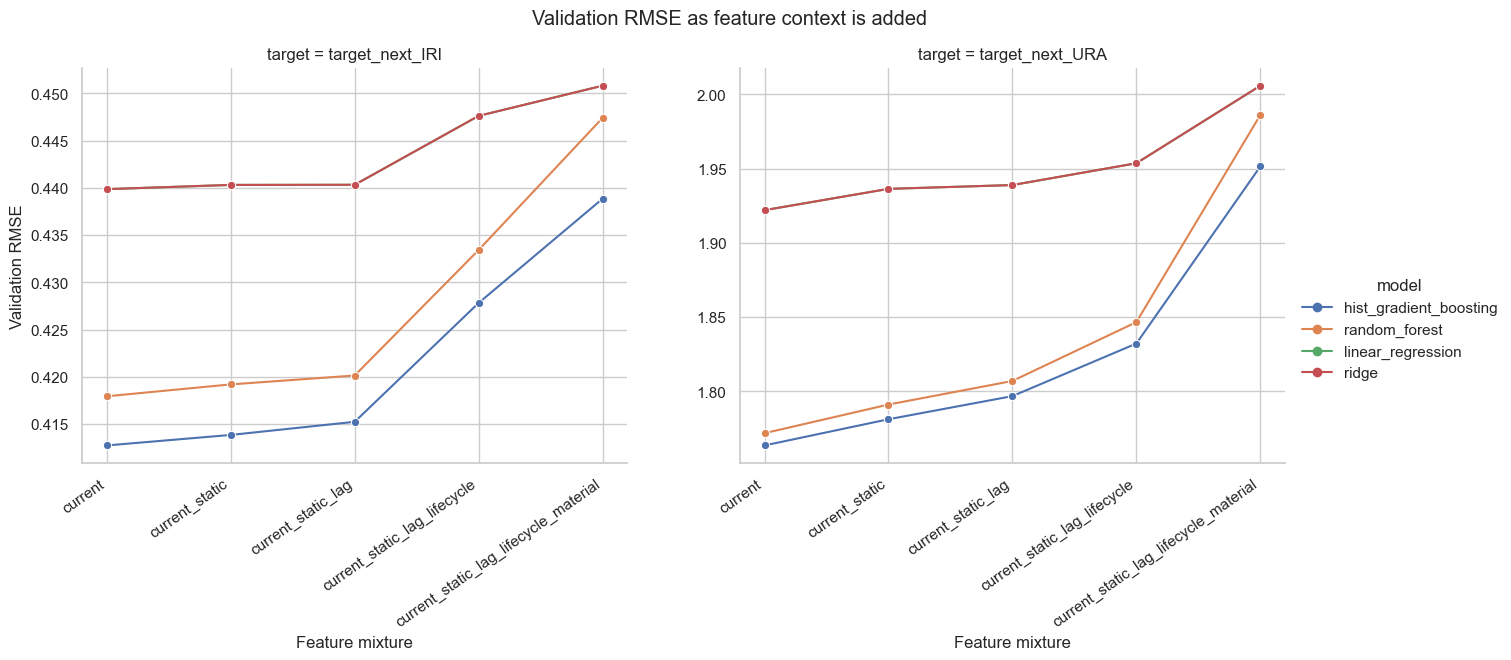

In [4]:
progress_models = ["hist_gradient_boosting", "random_forest", "linear_regression", "ridge"]
progress = validation.loc[validation["model"].isin(progress_models)].copy()
order = list(run_config["feature_mixtures"].keys())

g = sns.relplot(
    data=progress,
    x="feature_mixture",
    y="rmse",
    hue="model",
    col="target",
    kind="line",
    marker="o",
    height=5,
    aspect=1.35,
    facet_kws={"sharey": False},
)
for ax in g.axes.flat:
    ax.set_xticklabels(order, rotation=35, ha="right")
g.set_axis_labels("Feature mixture", "Validation RMSE")
g.fig.suptitle("Validation RMSE as feature context is added", y=1.04)
g.fig.savefig(FIG_DIR / "feature_progression_validation_rmse.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Overall Test Results

,model,target,target_type,feature_mixture,split,train_rows,evaluation_rows,mae,rmse,r2
0,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.232244,0.407645,0.852031
1,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,test,300000,575195,0.234435,0.412843,0.848233
2,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,150000,575195,0.238833,0.419889,0.843008
3,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.248870,0.434029,0.832256
4,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.248870,0.434029,0.832256
5,persistence,target_next_IRI,direct,persistence,test,3258128,575195,0.263025,0.474531,0.799489
6,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.150635,1.765230,0.840754
7,random_forest,target_next_URA,direct,current_static_lag_lifecycle_material,test,300000,575195,1.141090,1.774198,0.839131
8,gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,150000,575195,1.209294,1.841161,0.826759
9,linear_regression,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.286372,1.923522,0.810913


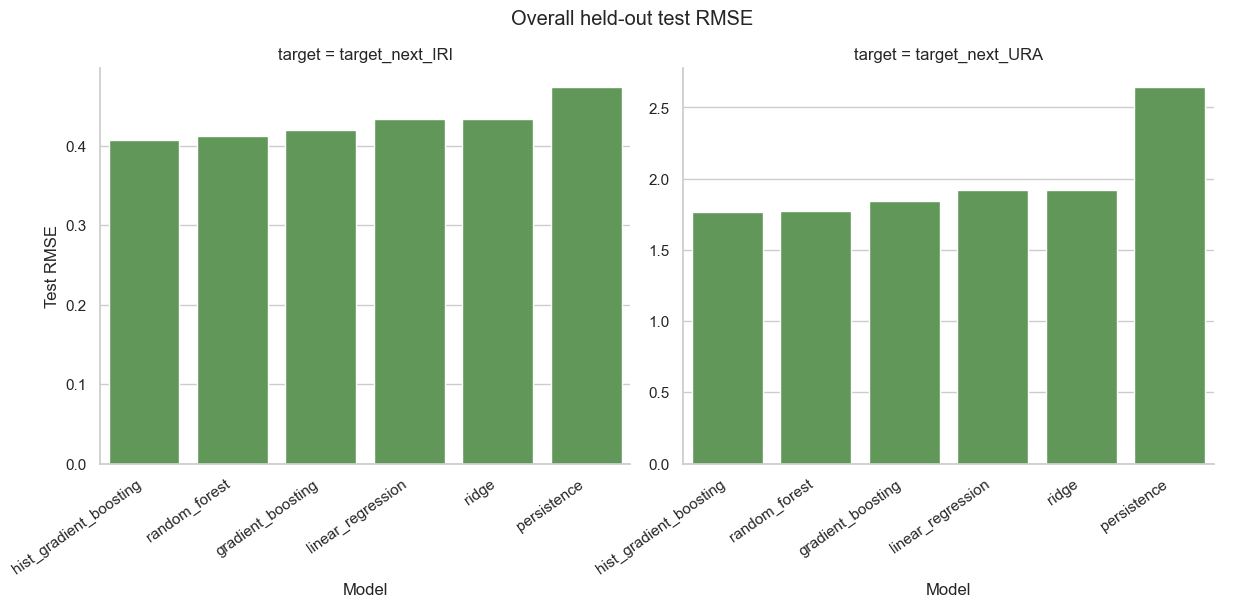

,model,target,target_type,feature_mixture,split,train_rows,evaluation_rows,mae,rmse,r2,persistence_rmse,rmse_improvement_pct
0,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.232244,0.407645,0.852031,0.474531,14.095345
1,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,test,300000,575195,0.234435,0.412843,0.848233,0.474531,12.999946
2,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,150000,575195,0.238833,0.419889,0.843008,0.474531,11.514953
3,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.248870,0.434029,0.832256,0.474531,8.535141
4,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.248870,0.434029,0.832256,0.474531,8.535141
5,persistence,target_next_IRI,direct,persistence,test,3258128,575195,0.263025,0.474531,0.799489,0.474531,0.000000
6,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.150635,1.765230,0.840754,2.645991,33.286627
7,random_forest,target_next_URA,direct,current_static_lag_lifecycle_material,test,300000,575195,1.141090,1.774198,0.839131,2.645991,32.947710
8,gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,150000,575195,1.209294,1.841161,0.826759,2.645991,30.416983
9,linear_regression,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.286372,1.923522,0.810913,2.645991,27.304279


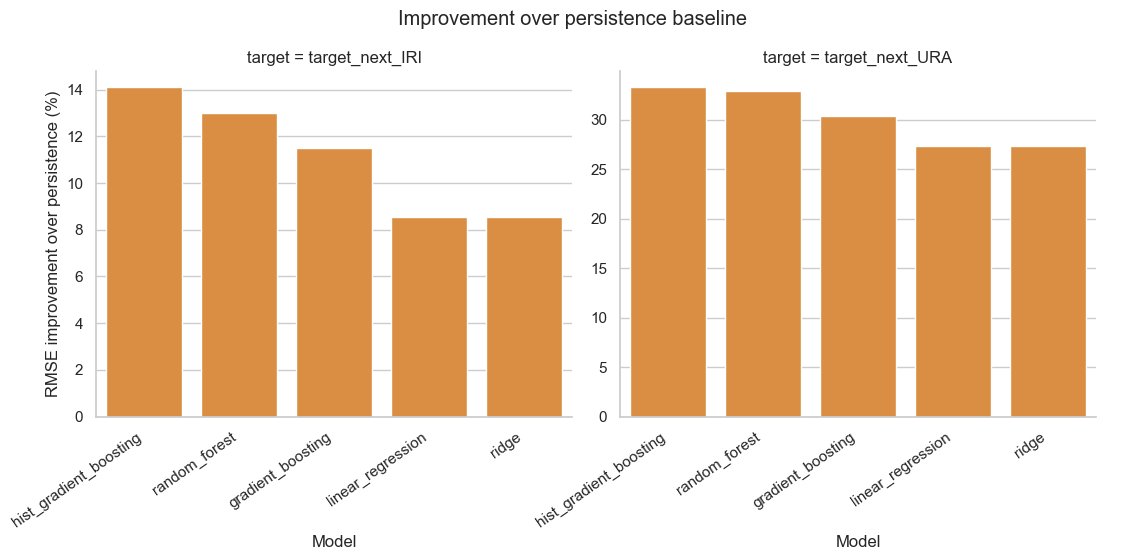

In [5]:
display(test_overall.sort_values(["target", "rmse"]))

g = sns.catplot(
    data=test_overall,
    x="model",
    y="rmse",
    col="target",
    kind="bar",
    height=5,
    aspect=1.2,
    sharey=False,
    color="#59A14F",
)
g.set_xticklabels(rotation=35, ha="right")
g.set_axis_labels("Model", "Test RMSE")
g.fig.suptitle("Overall held-out test RMSE", y=1.04)
g.fig.savefig(FIG_DIR / "overall_test_rmse.png", dpi=160, bbox_inches="tight")
plt.show()

persistence = test_overall.loc[test_overall["model"].eq("persistence"), ["target", "rmse"]].rename(columns={"rmse": "persistence_rmse"})
improvement = test_overall.merge(persistence, on="target")
improvement["rmse_improvement_pct"] = 100 * (improvement["persistence_rmse"] - improvement["rmse"]) / improvement["persistence_rmse"]
display(improvement.sort_values(["target", "rmse"]))

g = sns.catplot(
    data=improvement.loc[improvement["model"].ne("persistence")],
    x="model",
    y="rmse_improvement_pct",
    col="target",
    kind="bar",
    height=4.5,
    aspect=1.2,
    sharey=False,
    color="#F28E2B",
)
g.set_xticklabels(rotation=35, ha="right")
g.set_axis_labels("Model", "RMSE improvement over persistence (%)")
g.fig.suptitle("Improvement over persistence baseline", y=1.05)
g.fig.savefig(FIG_DIR / "improvement_over_persistence.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Direct vs Delta Target Results

,model,target,target_type,feature_mixture,split,train_rows,evaluation_rows,mae,rmse,r2
0,hist_gradient_boosting,target_next_IRI,delta_converted_to_actual,current_static_lag_lifecycle_material,test,3258128,575195,0.231849,0.407616,0.852052
1,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.232244,0.407645,0.852031
2,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,current_static_lag_lifecycle_material,test,3258128,575195,1.144561,1.754246,0.842729
3,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.150635,1.765230,0.840754


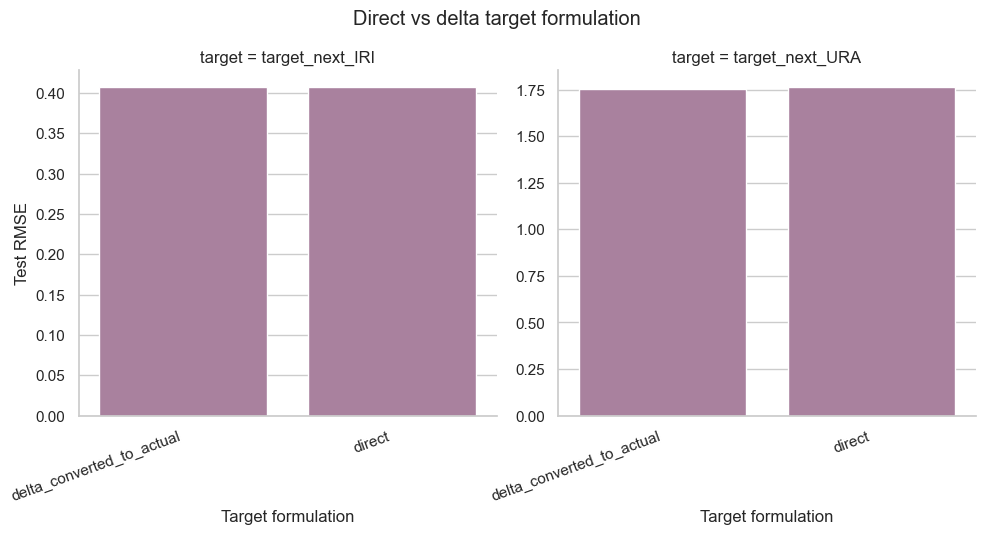

In [6]:
display(delta)

g = sns.catplot(
    data=delta,
    x="target_type",
    y="rmse",
    col="target",
    kind="bar",
    height=4.5,
    aspect=1.1,
    sharey=False,
    color="#B07AA1",
)
g.set_xticklabels(rotation=20, ha="right")
g.set_axis_labels("Target formulation", "Test RMSE")
g.fig.suptitle("Direct vs delta target formulation", y=1.05)
g.fig.savefig(FIG_DIR / "direct_vs_delta_rmse.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Horizon Window Results

,model,target,target_type,feature_mixture,group_type,group,evaluation_rows,mae,rmse,r2
54,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,horizon_window,1y,273751,0.167935,0.301756,0.861216
55,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,horizon_window,1y,273751,0.168818,0.304974,0.858240
56,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,horizon_window,1y,273751,0.173039,0.312874,0.850800
57,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,horizon_window,1y,273751,0.180417,0.324889,0.839122
58,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,horizon_window,1y,273751,0.180417,0.324889,0.839122
59,persistence,target_next_IRI,direct,persistence,horizon_window,1y,273751,0.181197,0.344280,0.819344
60,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,horizon_window,2y,65113,0.222105,0.377464,0.829431
61,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,horizon_window,2y,65113,0.223745,0.380111,0.827030
62,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,horizon_window,2y,65113,0.227742,0.387466,0.820271
63,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,horizon_window,2y,65113,0.231467,0.397235,0.811094


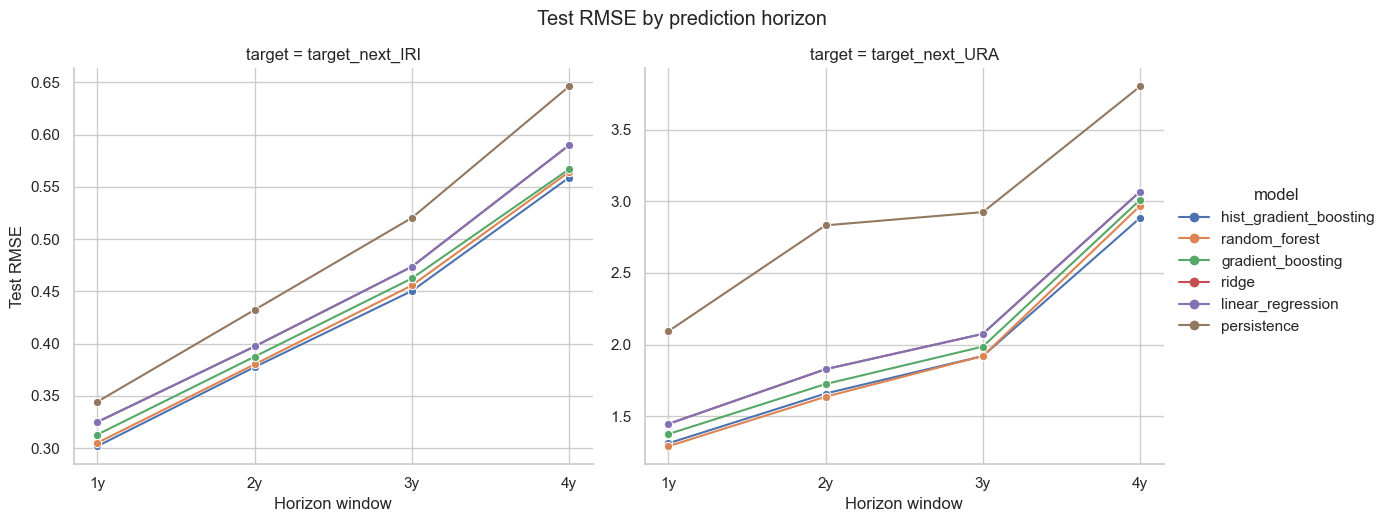

In [7]:
horizon = breakdowns.loc[breakdowns["group_type"].eq("horizon_window")].copy()
horizon["group"] = pd.Categorical(horizon["group"], categories=list(run_config["horizon_windows"].keys()), ordered=True)
display(horizon.sort_values(["target", "group", "rmse"]))

g = sns.relplot(
    data=horizon,
    x="group",
    y="rmse",
    hue="model",
    col="target",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2,
    facet_kws={"sharey": False},
)
g.set_axis_labels("Horizon window", "Test RMSE")
g.fig.suptitle("Test RMSE by prediction horizon", y=1.04)
g.fig.savefig(FIG_DIR / "horizon_window_rmse.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. ELY-Specific Results

,model,target,target_type,feature_mixture,group_type,group,evaluation_rows,mae,rmse,r2
0,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Epo,61939,0.242976,0.420668,0.848854
1,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Epo,61939,0.245018,0.423588,0.846748
2,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Epo,61939,0.249966,0.433011,0.839854
3,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Epo,61939,0.260387,0.446987,0.829349
4,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Epo,61939,0.260387,0.446987,0.829349
5,persistence,target_next_IRI,direct,persistence,ELY,Epo,61939,0.285333,0.493770,0.791758
6,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Kas,31743,0.197463,0.346564,0.875160
7,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Kas,31743,0.198652,0.351942,0.871255
8,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Kas,31743,0.203089,0.356752,0.867712
9,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Kas,31743,0.213005,0.375143,0.853721


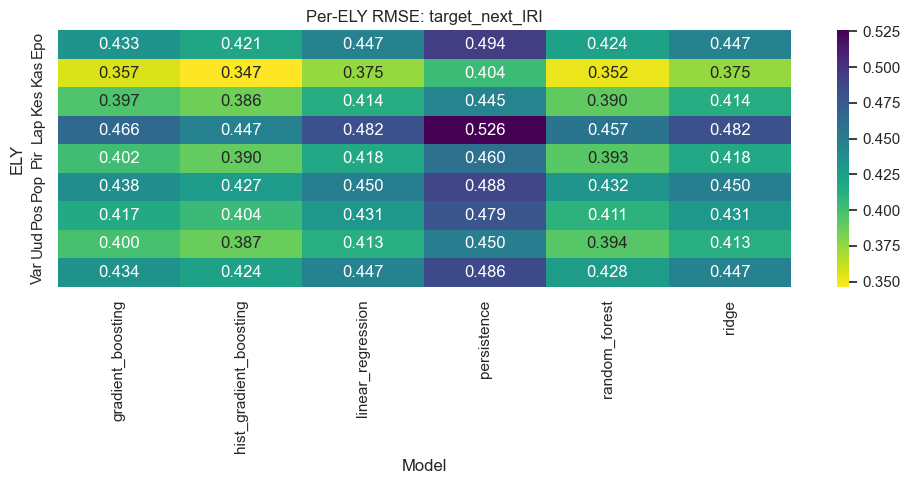

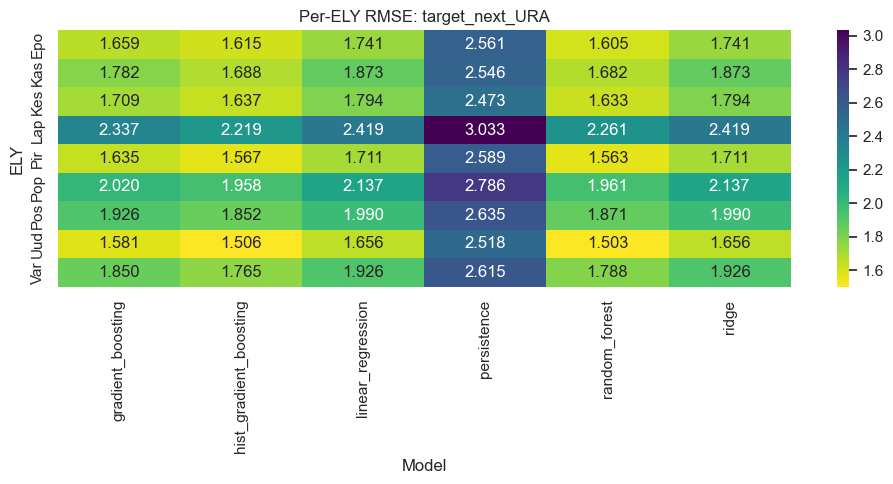

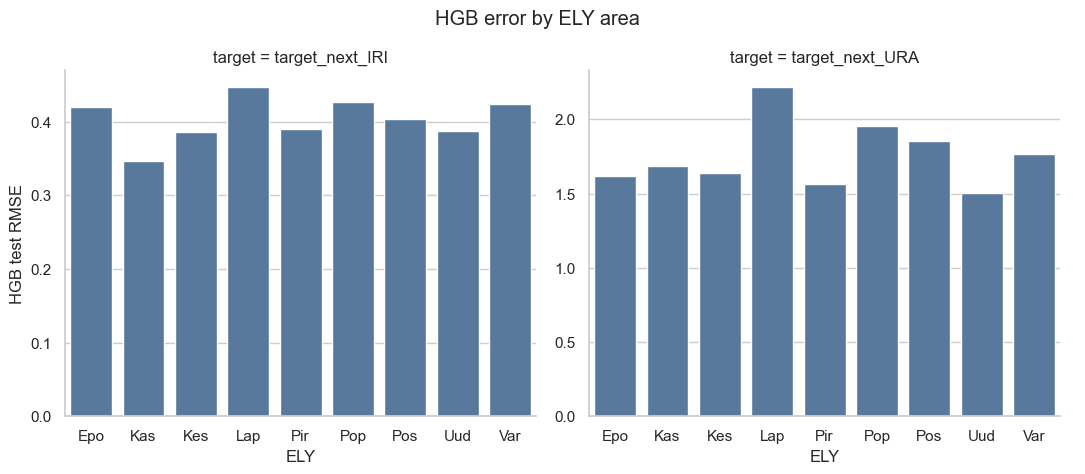

In [8]:
ely = breakdowns.loc[breakdowns["group_type"].eq("ELY")].copy()
display(ely.sort_values(["target", "group", "rmse"]).head(60))

for target in sorted(ely["target"].unique()):
    pivot = ely.loc[ely["target"].eq(target)].pivot_table(index="group", columns="model", values="rmse")
    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis_r")
    plt.title(f"Per-ELY RMSE: {target}")
    plt.xlabel("Model")
    plt.ylabel("ELY")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"ely_rmse_heatmap_{target}.png", dpi=160)
    plt.show()

hgb_ely = ely.loc[ely["model"].eq("hist_gradient_boosting")].copy()
g = sns.catplot(
    data=hgb_ely,
    x="group",
    y="rmse",
    col="target",
    kind="bar",
    height=4.5,
    aspect=1.2,
    sharey=False,
    color="#4E79A7",
)
g.set_axis_labels("ELY", "HGB test RMSE")
g.fig.suptitle("HGB error by ELY area", y=1.05)
g.fig.savefig(FIG_DIR / "hgb_rmse_by_ely.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Prediction Scatter and Residual Distributions

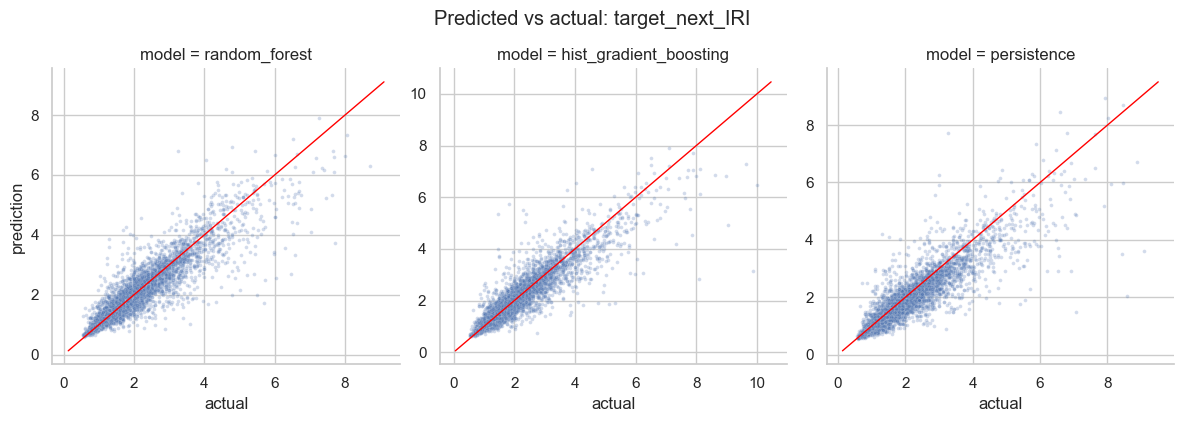

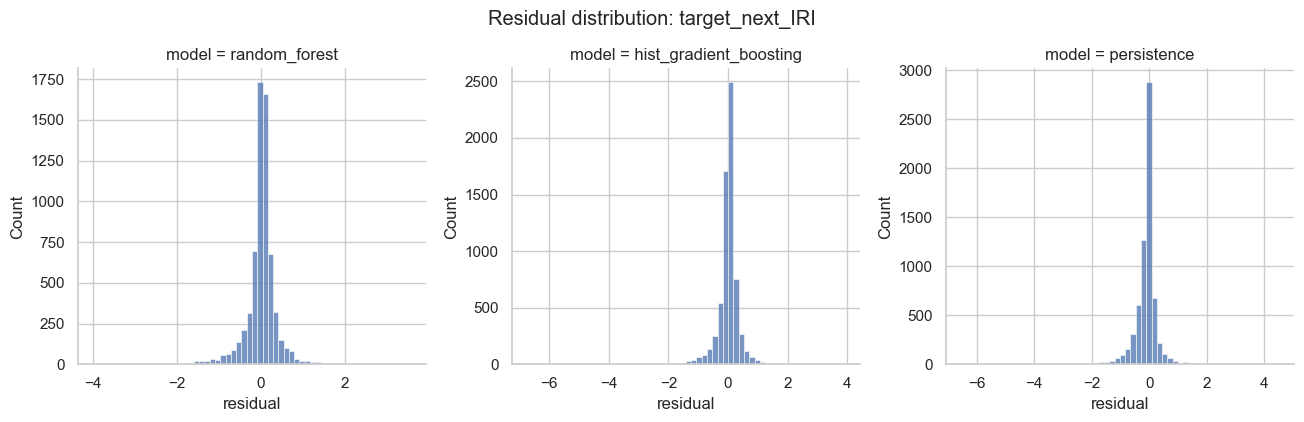

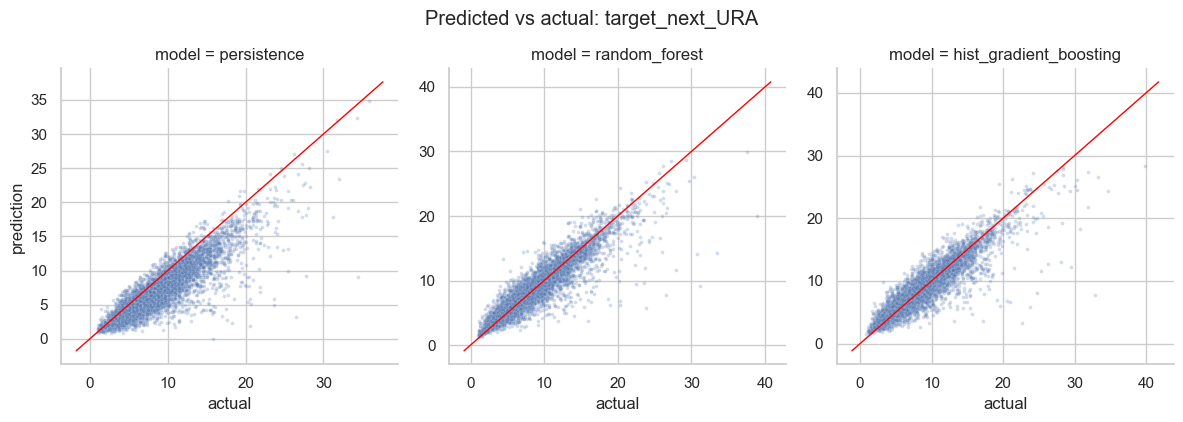

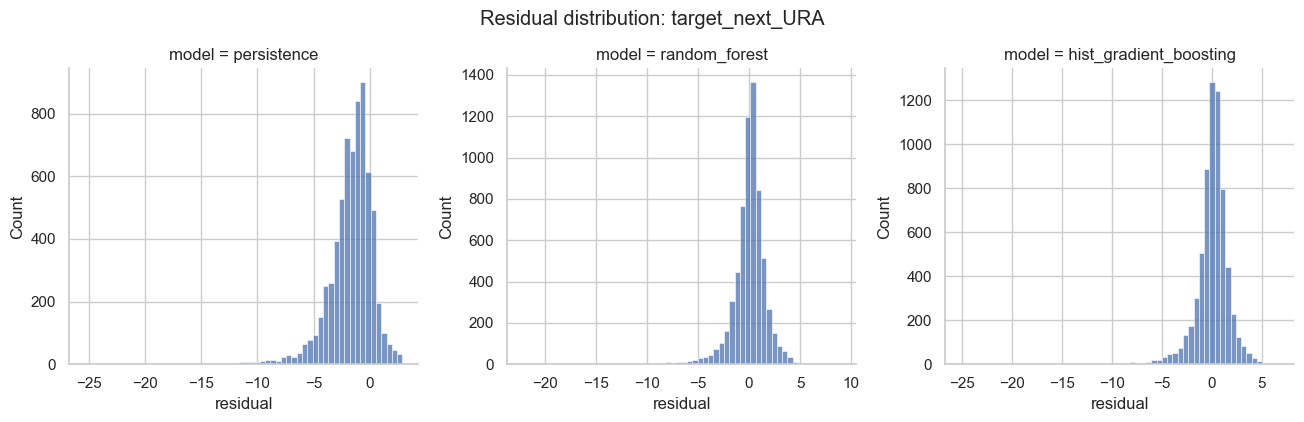

In [9]:
PLOT_SAMPLE_N = 80_000
pred_plot = predictions.copy()
if len(pred_plot) > PLOT_SAMPLE_N:
    pred_plot = pred_plot.sample(PLOT_SAMPLE_N, random_state=42)

selected_models = ["persistence", "hist_gradient_boosting", "random_forest"]
pred_plot = pred_plot.loc[pred_plot["model"].isin(selected_models)].copy()
pred_plot["actual"] = np.where(
    pred_plot["target"].eq("target_next_URA"),
    pred_plot["target_next_URA"],
    pred_plot["target_next_IRI"],
)
pred_plot["residual"] = pred_plot["prediction"] - pred_plot["actual"]

for target in sorted(pred_plot["target"].unique()):
    subset = pred_plot.loc[pred_plot["target"].eq(target)]
    g = sns.FacetGrid(subset, col="model", height=4, aspect=1, sharex=False, sharey=False)
    g.map_dataframe(sns.scatterplot, x="actual", y="prediction", s=7, alpha=0.25)
    for ax in g.axes.flat:
        lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
        hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
        ax.plot([lo, hi], [lo, hi], color="red", linewidth=1)
    g.fig.suptitle(f"Predicted vs actual: {target}", y=1.05)
    g.fig.savefig(FIG_DIR / f"predicted_vs_actual_{target}.png", dpi=160, bbox_inches="tight")
    plt.show()

    g = sns.FacetGrid(subset, col="model", height=4, aspect=1.1, sharex=False, sharey=False)
    g.map_dataframe(sns.histplot, x="residual", bins=60, kde=False)
    g.fig.suptitle(f"Residual distribution: {target}", y=1.05)
    g.fig.savefig(FIG_DIR / f"residual_distribution_{target}.png", dpi=160, bbox_inches="tight")
    plt.show()

## 10. Residuals by Horizon

,target,horizon_year_bin,count,mean,median
0,target_next_IRI,"(0, 1]",156389,0.172800,0.096665
1,target_next_IRI,"(1, 2]",176482,0.178668,0.098665
2,target_next_IRI,"(2, 3]",95180,0.265789,0.155369
3,target_next_IRI,"(3, 4]",88948,0.292353,0.173846
4,target_next_IRI,"(4, 5]",35260,0.354587,0.217888
5,target_next_IRI,"(5, 20]",22936,0.489404,0.303193
6,target_next_URA,"(0, 1]",156389,0.878883,0.616057
7,target_next_URA,"(1, 2]",176482,0.966820,0.679854
8,target_next_URA,"(2, 3]",95180,1.308082,0.923846
9,target_next_URA,"(3, 4]",88948,1.412914,0.975423


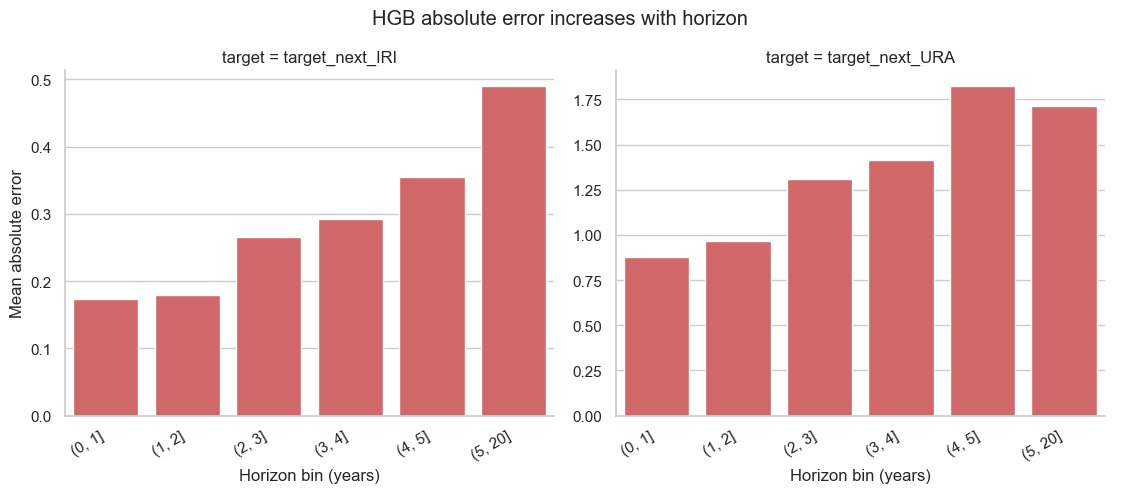

In [10]:
pred_hgb = predictions.loc[predictions["model"].eq("hist_gradient_boosting")].copy()
pred_hgb["actual"] = np.where(pred_hgb["target"].eq("target_next_URA"), pred_hgb["target_next_URA"], pred_hgb["target_next_IRI"])
pred_hgb["abs_error"] = (pred_hgb["prediction"] - pred_hgb["actual"]).abs()
pred_hgb["horizon_year_bin"] = pd.cut(pred_hgb["target_horizon_days"] / 365.25, bins=[0, 1, 2, 3, 4, 5, 20])

summary = pred_hgb.groupby(["target", "horizon_year_bin"], observed=True)["abs_error"].agg(["count", "mean", "median"]).reset_index()
display(summary)

g = sns.catplot(
    data=summary,
    x="horizon_year_bin",
    y="mean",
    col="target",
    kind="bar",
    height=4.5,
    aspect=1.25,
    sharey=False,
    color="#E15759",
)
g.set_xticklabels(rotation=30, ha="right")
g.set_axis_labels("Horizon bin (years)", "Mean absolute error")
g.fig.suptitle("HGB absolute error increases with horizon", y=1.05)
g.fig.savefig(FIG_DIR / "hgb_abs_error_by_horizon_bin.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Compact Conclusions

In [11]:
for target in sorted(test_overall["target"].unique()):
    target_rows = test_overall.loc[test_overall["target"].eq(target)].sort_values("rmse")
    best = target_rows.iloc[0]
    persistence_rmse = target_rows.loc[target_rows["model"].eq("persistence"), "rmse"].iloc[0]
    improvement = 100 * (persistence_rmse - best["rmse"]) / persistence_rmse
    print(f"{target}: best model is {best['model']} ({best['feature_mixture']}) with RMSE={best['rmse']:.3f}, "
          f"{improvement:.1f}% better than persistence.")

print(f"Figures saved to: {FIG_DIR.resolve()}")

target_next_IRI: best model is hist_gradient_boosting (current_static_lag_lifecycle_material) with RMSE=0.408, 14.1% better than persistence.
target_next_URA: best model is hist_gradient_boosting (current_static_lag_lifecycle_material) with RMSE=1.765, 33.3% better than persistence.
Figures saved to: C:\Users\Gamer2\Documents\school_sync\misc_maisteri_kurssit\case_studies_operations_research\Vayla_projekti\results\final_model_comparison\figures
